# Working with text

Peter Ralph  
2026-02-09

## Today

1.  Getting data off the web: “scraping”.

2.  Looking at the data: more working with words.

# Scraping

## Things to know

1.  Data access, data usage, and `robots.txt`.
2.  How a web page is structured.
3.  Getting a web page’s content into structured text.

## Are you a robot?

The legality and ethics of “scraping the web” are beyond the scope of
this course. Considerations:

1.  Read `<root url>/robots.txt`. (example:
    [imdb](https://www.imdb.com/robots.txt))
2.  Do not spam the website! Use a timeout if making lots of requests.
3.  Use an API if it exists! (not this: [OSM hit by bots, ignoring bulk
    download](https://www.reddit.com/r/openstreetmap/comments/1qpkz7l/openstreetmap_is_concerned_thousands_of_ai_bots/)
4.  Respect copyright, data usage agreements, etcetera.

## The structure of a web page: the Document Object Model

\![image from https://en.wikipedia.org/wiki/Document_Object_Model
showing a tree-like arrangement\]\](resources/DOM-model.png)

## Here’s a web page:

Live view: [resources/example.html](resources/example.html)

In [1]:
html_doc = """
<html>
  <head>
    <title>A simple example</title>
  </head>
  <body>
    <h1>Hello, world!</h1>
    <p class="first">This is a website.</p>
    <p>It contains words.</p>
  </body>
</html>
"""

*Draw the document tree!*

## How to navigate the tree:

Use the [developer
tools!](https://developer.mozilla.org/en-US/docs/Learn_web_development/Howto/Tools_and_setup/What_are_browser_developer_tools)

For instance: right-click on anything; select “inspect”.

## Fun in your browser:

Go to uoregon.edu, and

1.  Change some text. (inspect -\> click through to the text -\> edit)
2.  Make something dissappear. (inspect -\> add `display: none;` to the
    *element*’s CSS)
3.  Find the *path through the document tree* from the root (`html`) to
    something. (inspect)

## Doing this in python

We’ll use [Beautiful
Soup](https://beautiful-soup-4.readthedocs.io/en/latest/). Another
option is [`lxml.html`](https://lxml.de/lxmlhtml.html).

In [2]:
import bs4
soup = bs4.BeautifulSoup(html_doc, 'lxml')
print(soup.prettify())

<html>
 <head>
  <title>
   A simple example
  </title>
 </head>
 <body>
  <h1>
   Hello, world!
  </h1>
  <p class="first">
   This is a website.
  </p>
  <p>
   It contains words.
  </p>
 </body>
</html>



## Finding things:

For example all `<p>` tags:

In [3]:
soup.find_all("p")

[<p class="first">This is a website.</p>, <p>It contains words.</p>]

Other arguments narrow things down:

In [4]:
soup.find_all("p", class_="first")

[<p class="first">This is a website.</p>]

Or, using [CSS
selectors](https://developer.mozilla.org/en-US/docs/Web/CSS/Guides/Selectors):

In [5]:
soup.select("p.first")

[<p class="first">This is a website.</p>]

## Output:

Generally we want the *text* nested within certain tags. For instance:

In [6]:
for t in soup.body:
    if t.name == "h1":
        print("header", t.string)
    elif t.name == "p":
        print("paragraph:", t.string)

header Hello, world!
paragraph: This is a website.
paragraph: It contains words.


## Now welcome to the real world

Real-world websites are a *lot* more complex. Let’s have a look at
[IMSDb](https://imsdb.com/disclaimer.html).

In [14]:
import requests
session = requests.Session()
html_string = session.get("https://imsdb.com/scripts/Clueless.html")
doc = bs4.BeautifulSoup(html_string.content, 'lxml')
doc.title

<title>Clueless</title>

In [19]:
pre = doc.find_all("pre")[0]
for t in pre.find_all("tt")[30:40]:
    print(t.text)

Why?
MEL
Because he's your step-brother!
CHER
But you were hardly even married to his mother and
that was five years ago. Why do I have to see Josh?
(Watch those LIPS!!)
MEL
You divorce wives, not children.
CHER
Here.


In [27]:
t.parent

<p><tt><font size="+1">Here.</font></tt></p>

## Hands-on

Goals:

1.  Figure out what distinguishes the script from other parts of the web
    page.
2.  Figure out how to select those bits, in python.
3.  Separate out different bits of the script.
4.  Clean up the result.

In [12]:
pre = doc.find_all(name="p")
len(pre)

25

# Summarizing text

Next let’s look at the [script to
Interstellar](https://imsdb.com/scripts/Interstellar.html), available in
two files: [a CSV file of per-line
information](../data/interstellar_info.csv) and [a text file with one
“line” per line](../data/interstellar_lines.txt).

## Setup

In [8]:
import json, re, collections
import pandas as pd
import numpy as np
import plotnine as p9
import wordcloud
import matplotlib.pyplot as plt
import spacy

nlp = spacy.load("en_core_web_sm")

## What information do we have?

In [29]:
info = pd.read_csv("data/interstellar_info.csv", index_col=0)
info

,scene_num,what,who,directions
0,0,direction,NaN,NaN
1,0,direction,NaN,NaN
2,0,direction,NaN,NaN
3,0,direction,NaN,NaN
4,0,direction,NaN,NaN
...,...,...,...,...
2457,491,scene,NaN,NaN
2458,492,direction,NaN,NaN
2459,492,direction,NaN,NaN
2460,492,direction,NaN,NaN


##

In [31]:
info['what'].value_counts()

what
direction    1341
dialog        875
scene         246
Name: count, dtype: int64

In [30]:
info['who'].value_counts()

who
COOPER             305
BRAND              174
DOYLE               65
CASE                62
ROTH                60
MURPH               32
TARS                32
TOM                 26
DONALD              20
ANSEN               14
ADMINISTRATOR       12
DOCTOR              11
LIU                 10
PRINCIPAL            9
NSA AGENT            8
ASSISTANT            6
BRAND'S FATHER       5
BALLPLAYER           4
RIGGS                3
ROBOT                3
FARMER               3
EMILY COOPER         3
OLD ENGINEER         2
GOVERNMENT MAN       1
OLD MAN              1
ENGINEER ROBOT       1
CHINESE OFFICER      1
MURPH'S WIFE         1
WIFE                 1
Name: count, dtype: int64

In [35]:
info.loc[~info['directions'].isna(),:]

,scene_num,what,who,directions
20,6,dialog,ASSISTANT,(COVERS MICROPHONE)
23,6,dialog,ASSISTANT,"(pause, listens);(PAUSE)"
34,8,dialog,NSA AGENT,(SMILES)
42,8,dialog,ANSEN,(CONT'D);(MORE)
43,8,dialog,ANSEN,(CONT'D)
...,...,...,...,...
2399,476,dialog,ADMINISTRATOR,(CONT'D)
2403,476,dialog,COOPER,(SMILES)
2415,476,dialog,ADMINISTRATOR,(off his look);(QUIET)
2417,476,dialog,ADMINISTRATOR,(CONT'D);(BIG SMILE)


## Reading, and parsing, the lines

In [36]:
nlp = spacy.load("en_core_web_sm")

with open("data/interstellar_lines.txt", "r") as f:
    lines = [nlp(l.strip()) for l in f.readlines()]

for l in lines[:3]:
    print(l)

SPACE.
But not the dark lonely corner of it we're used to. This is a glittering inferno -- the center of a distant galaxy.
Suddenly, something TEARS past at incredible speed: a NEUTRON STAR. It SMASHES headlong through everything it encounters... planets, stars. Can anything stop this juggernaut?


## Let’s make a word cloud

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

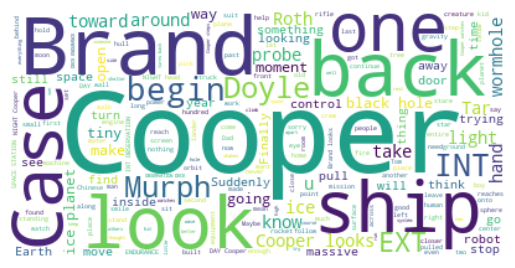

In [48]:
wc = wordcloud.WordCloud(
    random_state=123,
    background_color='white'
).generate(" ".join([l.text for l in lines]))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

## Let’s make a word cloud, take 2

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

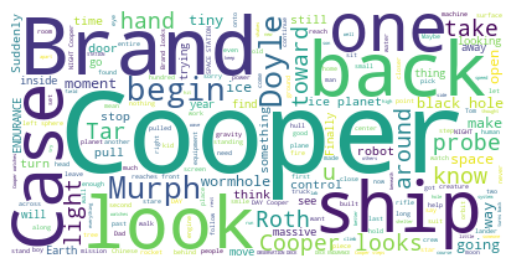

In [38]:
stopwords = set(wordcloud.STOPWORDS).union(["INT", "EXT"])

wc = wordcloud.WordCloud(
    stopwords=stopwords,
    random_state=123,
    background_color='white'
).generate(" ".join([l.text for l in lines]))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

## Let’s make a word cloud, take 3

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

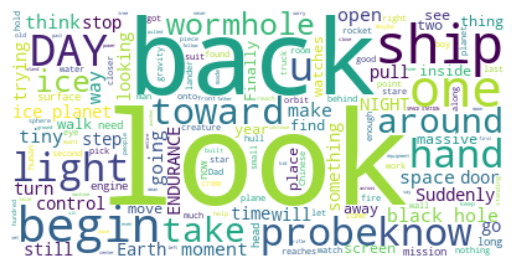

In [39]:
characters = [s.title() for s in set(info['who']) if isinstance(s, str)]

wc = wordcloud.WordCloud(
    stopwords=stopwords.union(characters),
    random_state=123,
    background_color='white'
).generate(" ".join([l.text for l in lines]))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

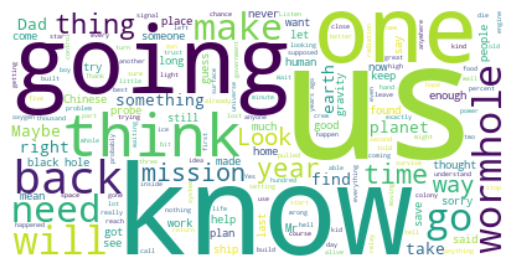

In [40]:
characters = [s.title() for s in set(info['who']) if isinstance(s, str)]

wc = wordcloud.WordCloud(
    stopwords=stopwords.union(characters),
    random_state=123,
    background_color='white'
).generate(" ".join([l.text for z, l in zip(info['what'] == 'dialog', lines) if z]))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

## Wordclouds by character:

In [41]:
def make_wordcloud(who):
    ut = info['who'] == who
    t = " ".join([l.text for z, l in zip(ut, lines) if z])
    wc = wordcloud.WordCloud(
        stopwords=stopwords.union(characters),
        random_state=123,
        background_color='white'
    ).generate(t)
    return wc

## What does Brand say?

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

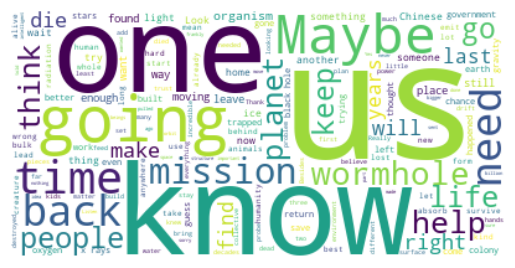

In [42]:
plt.imshow(make_wordcloud("BRAND"), interpolation='bilinear')
plt.axis("off")

## What does Cooper say?

It’s… interesting that she says “maybe” a lot more.

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

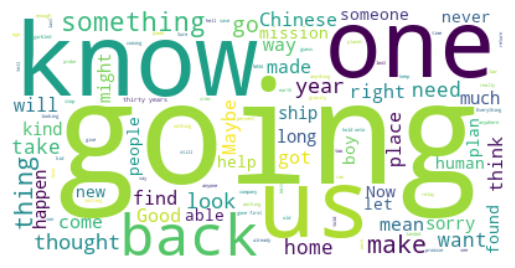

In [43]:
plt.imshow(make_wordcloud("COOPER"), interpolation='bilinear')
plt.axis("off")

## Parts of speech: set-up

In [45]:
import collections

chs = pd.DataFrame(info['who'].value_counts())

total = collections.Counter([t.pos_ for l in lines for t in l])
total

Counter({'NOUN': 6822,
         'PUNCT': 6141,
         'VERB': 5239,
         'ADP': 3977,
         'PRON': 3943,
         'DET': 3936,
         'PROPN': 2327,
         'AUX': 1958,
         'ADJ': 1933,
         'ADV': 1714,
         'PART': 1034,
         'CCONJ': 651,
         'SCONJ': 518,
         'NUM': 260,
         'INTJ': 59,
         'X': 2})

## Parts of speech: counting

In [46]:
for n in total:
    chs[n] = 0

for who in chs.index:
    ut = info['who'] == who
    c = collections.Counter([t.pos_ for z, l in zip(ut, lines) for t in l if z])
    for n in c:
        chs.loc[who, n] = c[n]

chs.head()

,count,PROPN,PUNCT,CCONJ,PART,DET,ADJ,NOUN,ADP,PRON,AUX,VERB,ADV,INTJ,SCONJ,NUM,X
who,,,,,,,,,,,,,,,,,
COOPER,305,52,571,39,175,203,142,366,218,598,337,496,176,24,82,41,0
BRAND,174,30,441,37,129,196,132,361,159,494,301,421,172,11,67,20,1
DOYLE,65,8,131,11,41,64,33,107,70,133,87,118,48,2,12,10,0
CASE,62,22,153,14,45,90,79,163,68,155,98,147,46,3,20,8,0
ROTH,60,9,165,19,64,87,52,134,79,183,103,182,57,5,22,14,0


## Parts of speech: plotting

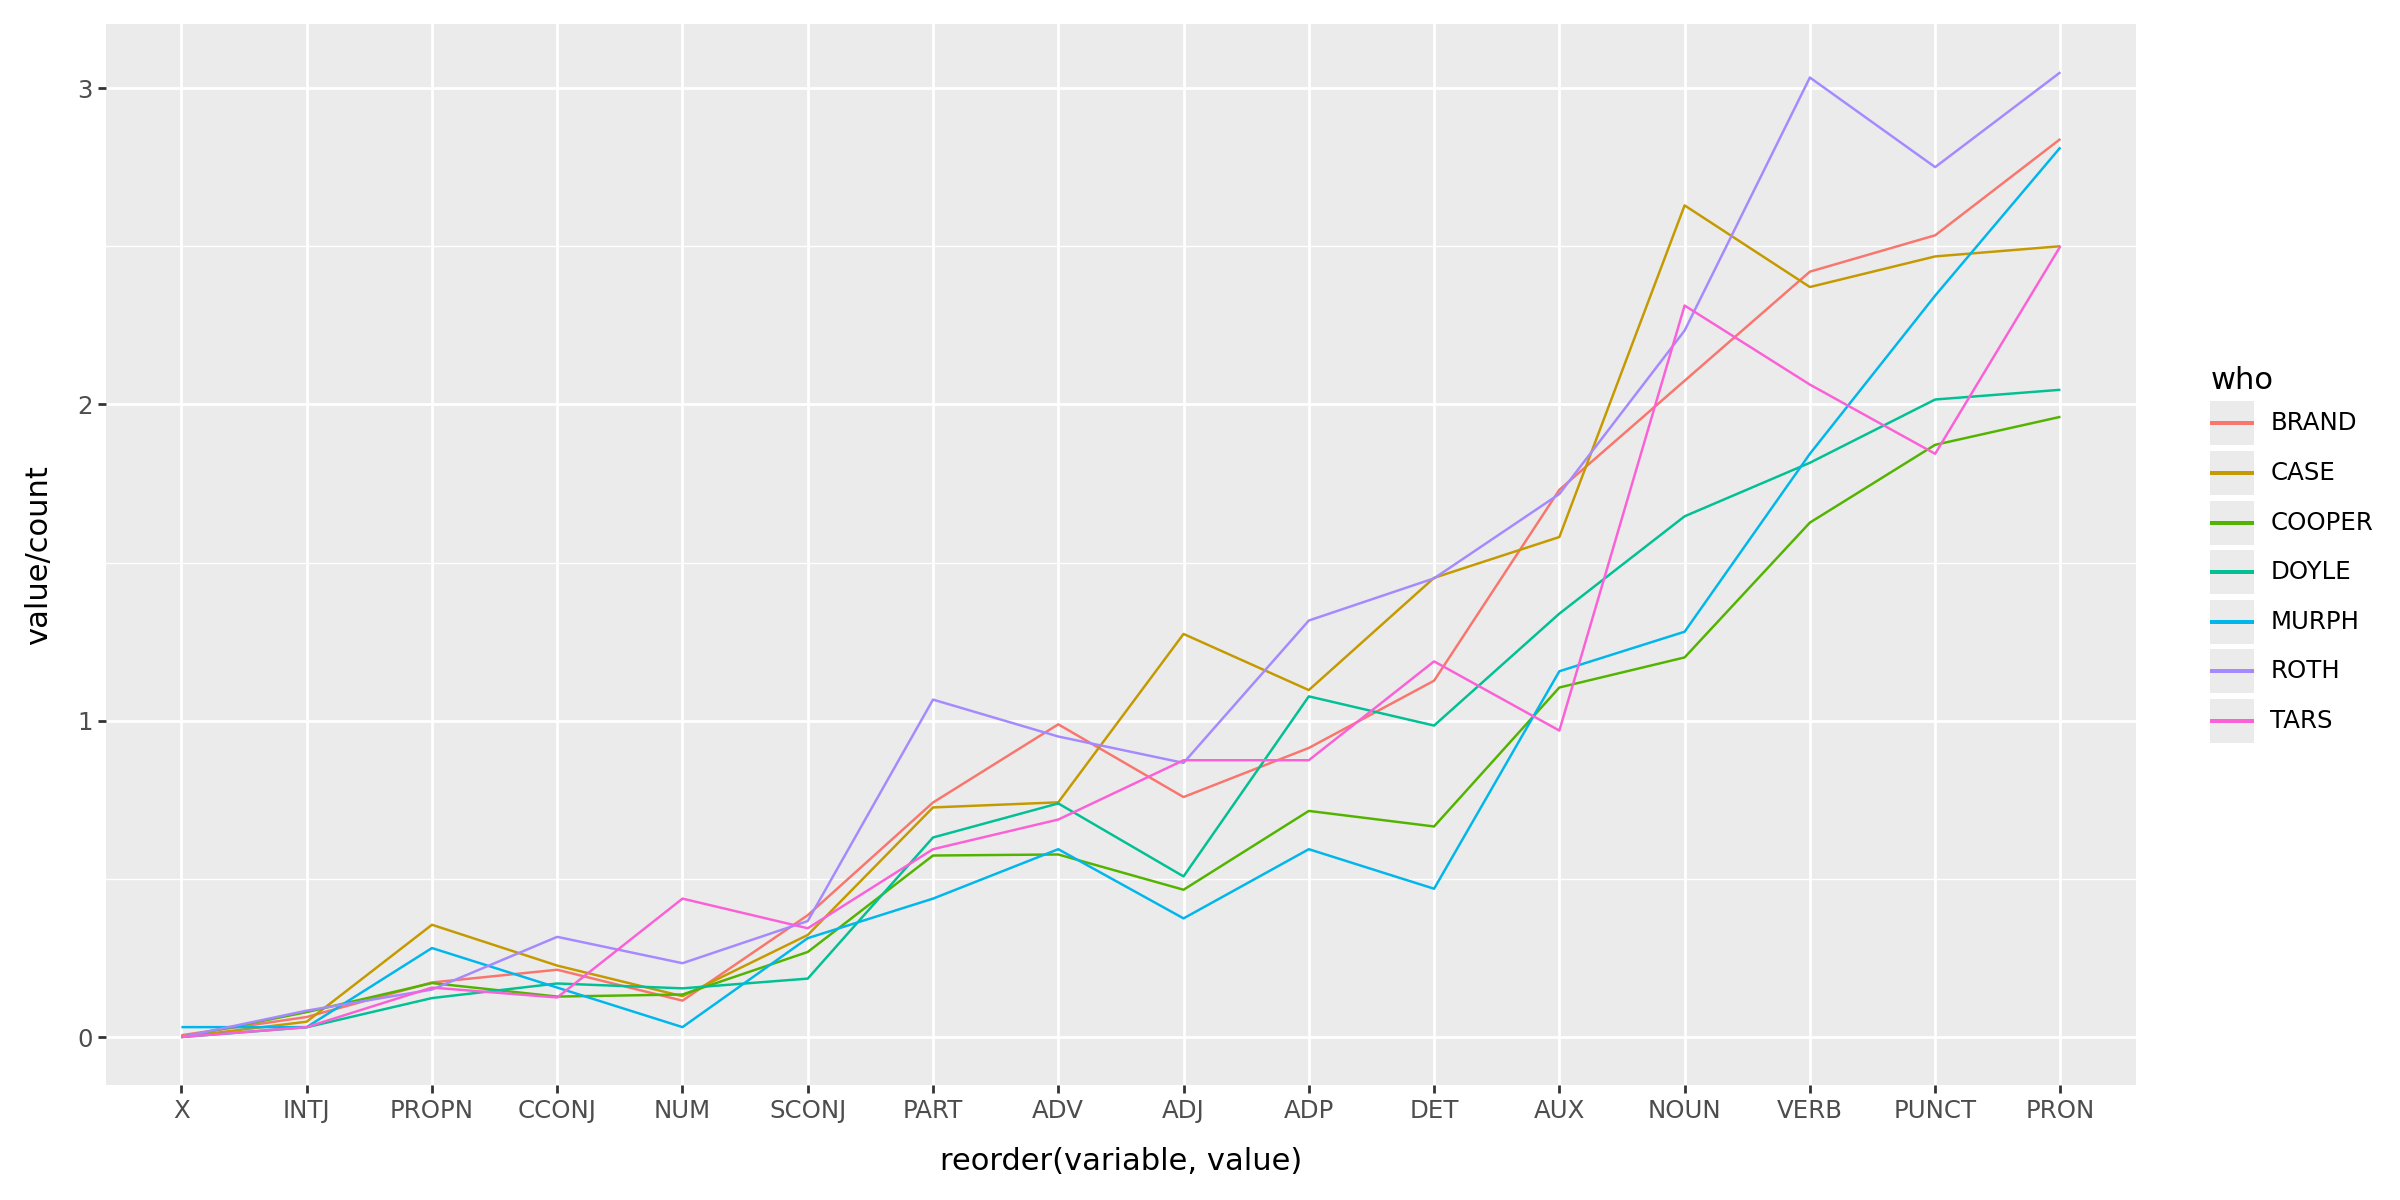

In [47]:
(
    chs
    .query("count > 30")
    .melt(id_vars=['count'], ignore_index=False)
    .reset_index()
    >>
    p9.ggplot(p9.aes(x='reorder(variable, value)', y='value/count', color='who', group='who'))
    + p9.geom_line()              
) + p9.theme(figure_size=(12,6))

## The Bechdel test?

*Challenge:* Does *Interstellar* pass the Bechdel test?